In [2]:
import serial
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import pandas as pd
from scipy.signal import find_peaks
import serial
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import pickle
import os


Reading values from STM32...
1988
1986
1988
1988
1988
1985
1988
1988
1985
1988
1989
1986
1985
1988
1986
1986
1986
1985
1987
1995
1991
1990
1988
1988
1988
1984
1986
1988
1986
1986
1986
1988
1985
1989
1988
1989
1986
1988
1990
1988
1987
1987
1992
1988
1988
1984
1985
1986
1983
1987
1989
1988
1988
1988
1987
1986
1988
1987
1987
1986
1984
1987
1982
1985
1989
1988
1988
1988
1988
1986
1983
1989
1987
1986
1987
1986
1985
1985
1987
1987
1988
1988
1988
1989
1986
1985
1985
1989
1989
1988
1986
1986
1986
1986
1988
1988
1990
1985
1983
1987
1989
1988
1985
1987
1986
1986
1990
1988
1988
1994
1985
1990
1990
1986
1984
1984
1986
1987
1988
1986
1987
1988
1989
1988
1988
1988
1988
1988
1984
1988
1986
1984
1988
1986
1984
1986
1988
1988
1985
1987
1987
1989
1988
1988
1989
1986
1984
1986
1987
1985
1984
1988
1987
1988
1988
1987
1987
1986
1987
1985
1988
1988
1988
1989
1989
1989
1987
1986
1984
1985
1984
1985
1986
1989
1988
1988
1988
1988
1986
1985
1985
1986
1987
1988
1988
1987
1988
1988
1986
1985
1985
1986
1989
1985
1

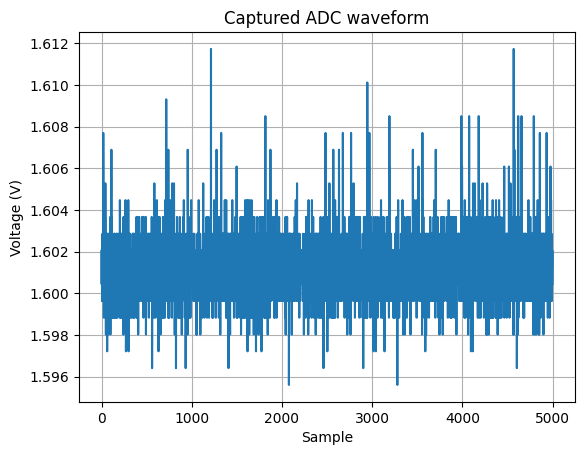

In [7]:
ser = serial.Serial('COM4', baudrate=115200)  # Open serial port
adc_values = []
print("Reading values from STM32...")

while len(adc_values) < 5000:
    line = ser.readline().decode().strip()
    try:
        val = int(line)
        print(val)  # Print the value to the console
        adc_values.append(val)
    except:
        pass

ser.close()
print("Captured waveform.")

# Convert to volts
vref = 3.3
adc = np.array(adc_values)
voltage = adc * vref / 4095
# Plot
plt.plot(voltage)
plt.title("Captured ADC waveform")
plt.xlabel("Sample")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()

Waiting for vibration spike...
Vibration detected, recording started.
Recording stopped.


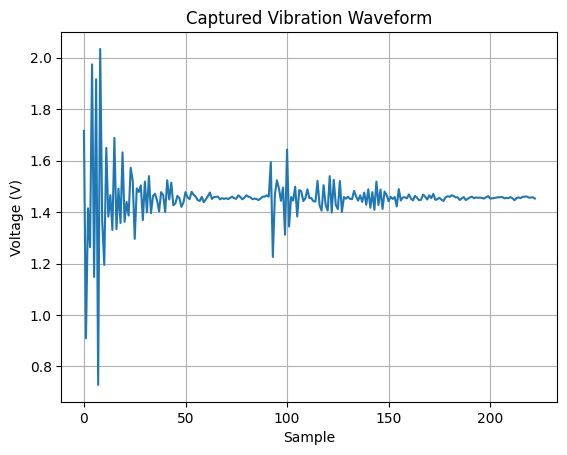

In [262]:
# === CONFIGURATION ===
ser = serial.Serial('COM4', baudrate=115200)
vref = 3
adc_resolution = 4095
baseline = 1987              # Typical idle value (adjust if needed)
trigger_threshold = 100       # Difference from baseline to start recording
max_samples = 2000            # Max samples after trigger
silence_duration = 100       # How long to wait with no activity before stopping

adc_values = []
recording = False
silence_counter = 0

print("Waiting for vibration spike...")

while True:
    line = ser.readline().decode().strip()
    try:
        val = int(line)
    except:
        continue

    diff = abs(val - baseline)

    if not recording:
        if diff > trigger_threshold:
            print("Vibration detected, recording started.")
            recording = True
            adc_values = [val]
            silence_counter = 0
    else:
        adc_values.append(val)

        if diff < trigger_threshold:
            silence_counter += 1
        else:
            silence_counter = 0

        # Stop if signal is quiet for too long or too many samples
        if silence_counter > silence_duration or len(adc_values) >= max_samples:
            print("Recording stopped.")
            break

ser.close()

# === PROCESS AND PLOT ===
adc = np.array(adc_values)
voltage = adc * vref / adc_resolution

plt.plot(voltage)
plt.title("Captured Vibration Waveform")
plt.xlabel("Sample")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()


In [263]:
# === Settings ===
SAMPLING_RATE = 1000
BASELINE = 1987
VREF = 3
ADC_RESOLUTION = 4096

# === Example ADC Values (Replace this with your actual incoming adc_values array) ===
# adc_values = [ ... ]  # Make sure adc_values is already captured
# For now, assume adc_values exists!

# === Feature Extraction ===
centered = (np.array(adc_values) - BASELINE) * (VREF / ADC_RESOLUTION)
N = len(centered)

peak_voltage = np.max(np.abs(centered))
signal_energy = np.sum(centered ** 2)
duration_ms = (N / SAMPLING_RATE) * 1000
zcr = ((centered[:-1] * centered[1:]) < 0).sum() / duration_ms * 1000 if duration_ms > 0 else 0

# FFT features
T = 1.0 / SAMPLING_RATE
yf = fft(centered)
xf = fftfreq(N, T)[:N//2]
fft_mag = 2.0/N * np.abs(yf[0:N//2])

dominant_freq = xf[np.argmax(fft_mag)] if np.any(fft_mag) else 0
spectral_centroid = np.sum(xf * fft_mag) / np.sum(fft_mag) if np.sum(fft_mag) > 0 else 0
spectral_energy = np.sum(fft_mag**2)

# === Display Extracted Features ===
print("Peak Voltage:", peak_voltage)
print("Signal Energy:", signal_energy)
print("Duration (ms):", duration_ms)
print("Zero Crossing Rate:", zcr)
print("Dominant Frequency:", dominant_freq)
print("Spectral Centroid:", spectral_centroid)
print("Spectral Energy:", spectral_energy)

# === Ask User for Labels ===
material = "Eraser"
distance = 30
height = 30

# === Create a dictionary of the data ===
data_entry = {
    "Material": material,
    "Distance (cm)": distance,
    "Height (cm)": height,
    "Peak Voltage (V)": peak_voltage,
    "Signal Energy (J)": signal_energy,
    "Duration (ms)": duration_ms,
    "ZCR": zcr,
    "Dominant Frequency (Hz)": dominant_freq,
    "Spectral Centroid (Hz)": spectral_centroid,
    "Spectral Energy": spectral_energy
}

# === Save or Append to CSV ===
csv_filename = "vibration_data_collection_set1.csv"

# If file exists, append, else create new
if os.path.exists(csv_filename):
    df_existing = pd.read_csv(csv_filename)
    df_updated = pd.concat([df_existing, pd.DataFrame([data_entry])], ignore_index=True)
else:
    df_updated = pd.DataFrame([data_entry])

df_updated.to_csv(csv_filename, index=False)

print(f"✅ Data saved to {csv_filename}")


Peak Voltage: 0.727294921875
Signal Energy: 2.4150513410568237
Duration (ms): 223.0
Zero Crossing Rate: 587.4439461883409
Dominant Frequency: 457.3991031390134
Spectral Centroid: 335.26003447610606
Spectral Energy: 0.020966198747524534
✅ Data saved to vibration_data_collection_set1.csv


Material Accuracy: 0.8666666666666667
Distance Accuracy: 0.7333333333333333
Height Accuracy: 0.7333333333333333


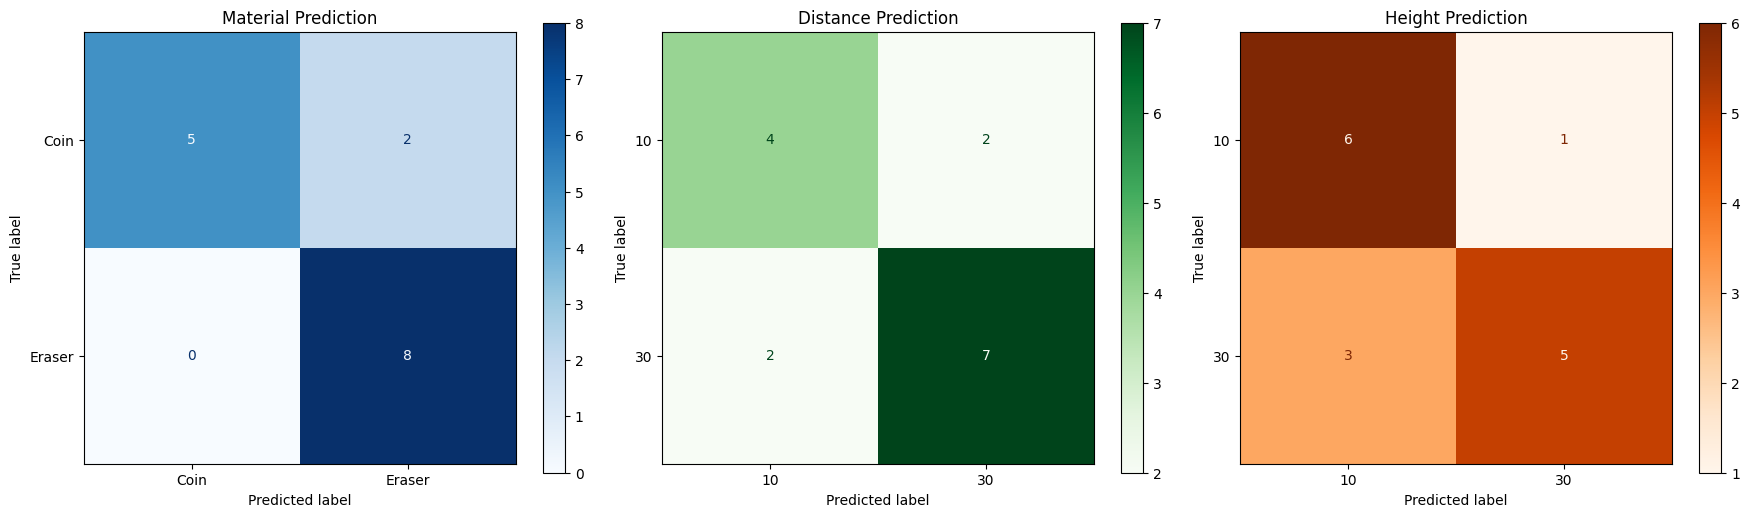

✅ Models and scaler saved successfully!


In [272]:
# === 1. Load Your Full Dataset ===
df = pd.read_csv(r'C:\Python_Env\ECE4179\TRC3500\Normal Mode\vibration_data_merged_set1.csv')  # <- use your file here

# === 2. Separate Features and Labels ===
X = df[[
    "Peak Voltage (V)", "Signal Energy (J)", "Duration (ms)", "ZCR",
    "Dominant Frequency (Hz)", "Spectral Centroid (Hz)", "Spectral Energy"
]]

y_material = df["Material"]
y_distance = df["Distance (cm)"]
y_height = df["Height (cm)"]

# === 3. Scale Features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 4. Encode Material Labels ===
material_encoder = LabelEncoder()
y_material_encoded = material_encoder.fit_transform(y_material)

# === 5. Train/Test Split ===
X_train, X_test, y_mat_train, y_mat_test = train_test_split(X_scaled, y_material_encoded, test_size=0.3, random_state=42)
_, _, y_dist_train, y_dist_test = train_test_split(X_scaled, y_distance, test_size=0.3, random_state=42)
_, _, y_ht_train, y_ht_test = train_test_split(X_scaled, y_height, test_size=0.3, random_state=42)

# === 6. Train Random Forest Classifiers ===
clf_material = RandomForestClassifier(max_depth=5, random_state=42)
clf_material.fit(X_train, y_mat_train)

clf_distance = RandomForestClassifier(max_depth=5, random_state=42)
clf_distance.fit(X_train, y_dist_train)

clf_height = RandomForestClassifier(max_depth=5, random_state=42)
clf_height.fit(X_train, y_ht_train)

# === 7. Evaluate
print("Material Accuracy:", accuracy_score(y_mat_test, clf_material.predict(X_test)))
print("Distance Accuracy:", accuracy_score(y_dist_test, clf_distance.predict(X_test)))
print("Height Accuracy:", accuracy_score(y_ht_test, clf_height.predict(X_test)))

# Plot confusion matrices
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_mat_test, clf_material.predict(X_test), display_labels=material_encoder.classes_, ax=axs[0], cmap='Blues')
axs[0].set_title("Material Prediction")
ConfusionMatrixDisplay.from_predictions(y_dist_test, clf_distance.predict(X_test), ax=axs[1], cmap='Greens')
axs[1].set_title("Distance Prediction")
ConfusionMatrixDisplay.from_predictions(y_ht_test, clf_height.predict(X_test), ax=axs[2], cmap='Oranges')
axs[2].set_title("Height Prediction")
plt.tight_layout()
plt.show()

# === 8. Save models and scaler ===
with open('clf_material_set3.pkl', 'wb') as f:
    pickle.dump(clf_material, f)
with open('clf_distance_set3.pkl', 'wb') as f:
    pickle.dump(clf_distance, f)
with open('clf_height_set3.pkl', 'wb') as f:
    pickle.dump(clf_height, f)
with open('scaler_set3.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('material_encoder_set3.pkl', 'wb') as f:
    pickle.dump(material_encoder, f)

print("✅ Models and scaler saved successfully!")

In [124]:
param_grid = {
    'max_depth': [5, 10, None],
    'n_estimators': [50, 100, 200],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_scaled, y_material_encoded)

print("Best Hyperparameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Hyperparameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# === Load models ===
with open('clf_material.pkl', 'rb') as f:
    clf_material = pickle.load(f)
with open('clf_distance.pkl', 'rb') as f:
    clf_distance = pickle.load(f)
with open('clf_height.pkl', 'rb') as f:
    clf_height = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('material_encoder.pkl', 'rb') as f:
    material_encoder = pickle.load(f)

# === Settings ===
SERIAL_PORT = 'COM4'
BAUDRATE = 115200
BASELINE = 1987
VREF = 3
ADC_RESOLUTION = 4096
SAMPLING_RATE = 1000
THRESHOLD = 100
QUIET_COUNT = 100
MAX_SAMPLES = 2000

def extract_features(samples):
    centered = (np.array(samples) - BASELINE) * (VREF / ADC_RESOLUTION)
    N = len(centered)

    peak_voltage = np.max(np.abs(centered))
    signal_energy = np.sum(centered ** 2)
    duration_ms = (N / SAMPLING_RATE) * 1000
    zcr = ((centered[:-1] * centered[1:]) < 0).sum() / duration_ms * 1000 if duration_ms > 0 else 0

    T = 1.0 / SAMPLING_RATE
    yf = fft(centered)
    xf = fftfreq(N, T)[:N//2]
    fft_mag = 2.0/N * np.abs(yf[0:N//2])

    dominant_freq = xf[np.argmax(fft_mag)] if np.any(fft_mag) else 0
    spectral_centroid = np.sum(xf * fft_mag) / np.sum(fft_mag) if np.sum(fft_mag) > 0 else 0
    spectral_energy = np.sum(fft_mag**2)

    return {
        "Peak Voltage (V)": peak_voltage,
        "Signal Energy (J)": signal_energy,
        "Duration (ms)": duration_ms,
        "ZCR": zcr,
        "Dominant Frequency (Hz)": dominant_freq,
        "Spectral Centroid (Hz)": spectral_centroid,
        "Spectral Energy": spectral_energy
    }

# === Serial Listen ===
ser = serial.Serial(SERIAL_PORT, BAUDRATE, timeout=1)
print("Listening for vibration...")

while True:
    try:
        line = ser.readline().decode('utf-8').strip()
        if not line:
            continue
        try:
            adc_val = int(line)
        except ValueError:
            continue

        if abs(adc_val - BASELINE) > THRESHOLD:
            print("Vibration detected!")
            samples = [adc_val]
            silent_count = 0

            while True:
                line = ser.readline().decode('utf-8').strip()
                if not line:
                    continue
                try:
                    val = int(line)
                    samples.append(val)
                    if abs(val - BASELINE) < 20:
                        silent_count += 1
                    else:
                        silent_count = 0
                    if silent_count > QUIET_COUNT or len(samples) > MAX_SAMPLES:
                        break
                except:
                    continue

            features_dict = extract_features(samples)
            features_array = np.array(list(features_dict.values())).reshape(1, -1)
            features_scaled = scaler.transform(features_array)

            material_pred = clf_material.predict(features_scaled)[0]
            distance_pred = clf_distance.predict(features_scaled)[0]
            height_pred = clf_height.predict(features_scaled)[0]

            material_name = material_encoder.inverse_transform([material_pred])[0]

            print(f"\nPrediction: {material_name}, {distance_pred}cm, {height_pred}cm")
            print("==================================")

            # Ask user if prediction is correct
            correct = input("Is the prediction correct? (y/n): ").lower()

            if correct != 'y':
                # Manual labeling
                true_material = input("Enter true material (e.g., Coin, Eraser): ").strip()
                true_distance = input("Enter true distance (cm): ").strip()
                true_height = input("Enter true height (cm): ").strip()

                # Save wrong prediction for future retraining
                wrong_entry = {
                    "Material": true_material,
                    "Distance (cm)": true_distance,
                    "Height (cm)": true_height,
                    **features_dict
                }

                # Append to file
                try:
                    df_wrong = pd.read_csv('wrong_predictions.csv')
                    df_wrong = pd.concat([df_wrong, pd.DataFrame([wrong_entry])], ignore_index=True)
                except FileNotFoundError:
                    df_wrong = pd.DataFrame([wrong_entry])

                df_wrong.to_csv('wrong_predictions.csv', index=False)
                print("Wrong prediction logged for retraining!\n")

    except KeyboardInterrupt:
        print("Stopped.")
        ser.close()
        break


Listening for vibration...
Vibration detected!

Prediction: Coin, 10cm, 30cm
Wrong prediction logged for retraining!

Vibration detected!

Prediction: Coin, 10cm, 30cm
Wrong prediction logged for retraining!

Vibration detected!

Prediction: Coin, 10cm, 30cm
Wrong prediction logged for retraining!

Vibration detected!


In [270]:
# Load the main dataset
df_clean = pd.read_csv(r'C:\Python_Env\ECE4179\TRC3500\Normal Mode\vibration_data_collection_set1.csv')

# Try to load wrong predictions
try:
    df_wrong = pd.read_csv(r'C:\Python_Env\ECE4179\TRC3500\Normal Mode\wrong_predictions_set1.csv')

    # Combine clean + wrong corrections
    df_combined = pd.concat([df_clean, df_wrong], ignore_index=True)

    # Save the new merged dataset
    df_combined.to_csv('vibration_data_merged_set1.csv', index=False)
    print(f"✅ Merged {len(df_wrong)} wrong samples. Updated 'vibration_data_merged.csv' saved successfully.")

    # Optional: Clear wrong_predictions.csv after merging
    import os
    os.remove('Normal Mode\wrong_predictions_set1.csv')
    print("✅ Cleared 'wrong_predictions.csv' after merging.")

except FileNotFoundError:
    print("⚠️ No 'wrong_predictions.csv' found. Using only the clean dataset.")
    df_combined = df_clean


✅ Merged 16 wrong samples. Updated 'vibration_data_merged.csv' saved successfully.
⚠️ No 'wrong_predictions.csv' found. Using only the clean dataset.


<>:17: SyntaxWarning: invalid escape sequence '\w'
<>:17: SyntaxWarning: invalid escape sequence '\w'
C:\Users\sherm\AppData\Local\Temp\ipykernel_26772\3525961185.py:17: SyntaxWarning: invalid escape sequence '\w'
  os.remove('Normal Mode\wrong_predictions_set1.csv')
